In [16]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from typing import Optional
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from dotenv import load_dotenv

In [17]:
class Numbers(BaseModel):
    num1: int
    num2: int

    sum_value: int | None = None
    mult_value: int | None = None
    concat_value: str | None = None
    summary: str | None = None

In [18]:
model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [19]:
def sum_values(state: Numbers):
    sum_v = state.num1 + state.num2
    return {"sum_value": sum_v}

In [20]:
def mult_values(state: Numbers):
    multi_v = state.num1 * state.num2
    return {"mult_value": multi_v}

In [21]:
def concat_values(state: Numbers):
    concat_v = f"{state.num1}{state.num2}"
    return {"concat_value": concat_v}

In [23]:
def summerize_score(state: Numbers):
    prompt = PromptTemplate.from_template(
        "you got multiplication value {mult_value}, sum values {sum_value} and concat_values {concat_value}. "
        "Your task is to summarize this and print it in a style like Jack Sparrow is telling it."
    )

    updated_prompt = prompt.invoke(
        {
            "mult_value": state.mult_value,
            "concat_value": state.concat_value,
            "sum_value": state.sum_value,
        }
    )

    result = model.invoke(updated_prompt)

    return {"summary": result.content}
    

In [24]:
# define graph
graph = StateGraph(Numbers)

# add notdes
graph.add_node('multiplication', mult_values)
graph.add_node('addition', sum_values)
graph.add_node('concatination', concat_values)
graph.add_node('summerization', summerize_score)


# add edges
graph.add_edge(START, 'multiplication')
graph.add_edge(START, 'addition')
graph.add_edge(START, 'concatination')

graph.add_edge('multiplication', 'summerization')
graph.add_edge('addition', 'summerization')
graph.add_edge('concatination', 'summerization')

graph.add_edge('summerization', END)


workflow = graph.compile()





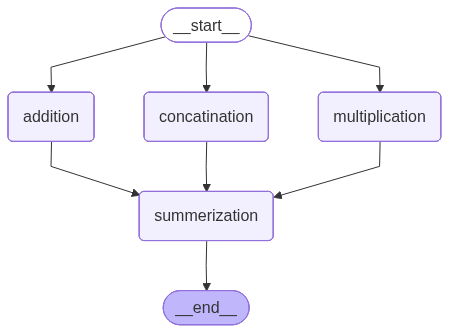

In [25]:
workflow

In [27]:
# execute
result = workflow.invoke({'num1': 20, 'num2': 30})

print(result['summary'])

Ahoy there, matey! Gather 'round and lend me yer ear, for I’ve got a tale of numbers that be as curious as a treasure map! 

Picture this: a grand multiplication, a mighty 600, like the gold doubloons in me chest! Aye, that be a fine haul indeed! Then, we’ve got a sum, a jolly 50, like the crew gathered for a round of rum after a long voyage. And let’s not forget the concat_values, a curious 2030, like the year we’ll sail into the horizon, chasing the winds of fortune!

So there ye have it, a fine trio of figures, all woven together like the sails of me ship! Now, off ye go, and may the winds be ever in yer favor! Savvy?
